In [ ]:
#Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import pandas as pd

#style set
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

#data load
BASE_DIR = Path.cwd().parent
df = pd.read_csv(BASE_DIR / "data" / "features" / "engineered_features.csv")
df.head()
print(f"Dataset shape: {df.shape}")
print(f"No-show rate: {df['no_show'].mean():.2%}")

Dataset shape: (71959, 38)
No-show rate: 28.52%


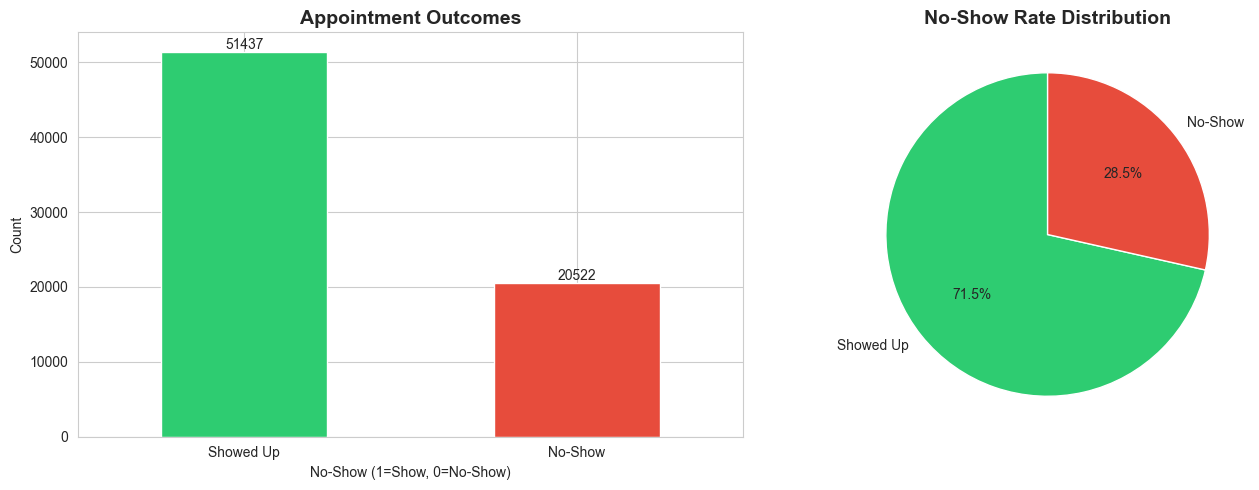


📊 Business Impact:
Total appointments: 71,959
No-shows: 20,522
No-show rate: 28.52%
Estimated revenue loss (@ $200/appointment): $4,104,400


In [3]:
#cell 2: target variable distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

#plot count
df['no_show'].value_counts().plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Appointment Outcomes', fontsize=14, fontweight='bold')
ax1.set_xlabel('No-Show (1=Show, 0=No-Show)')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['Showed Up', 'No-Show'], rotation=0)

#add percentage
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d')
    
#chart pie
no_show_counts = df['no_show'].value_counts()
ax2.pie(no_show_counts, labels=['Showed Up', 'No-Show'], autopct='%1.1f%%',
       colors=['#2ecc71', '#e74c3c'], startangle=90)
ax2.set_title('No-Show Rate Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\darle\Documents\!Bryan Projects\healthcare-no-show-prediction\docs\figures\target_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Business Impact:")
print(f"Total appointments: {len(df):,}")
print(f"No-shows: {df['no_show'].sum():,}")
print(f"No-show rate: {df['no_show'].mean():.2%}")
print(f"Estimated revenue loss (@ $200/appointment): ${df['no_show'].sum() * 200:,}")

C:\Users\darle\AppData\Local\Temp\ipykernel_11012\4046828740.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  no_show_by_lead = df.groupby(lead_time_bins)['no_show'].agg(['mean', 'count'])


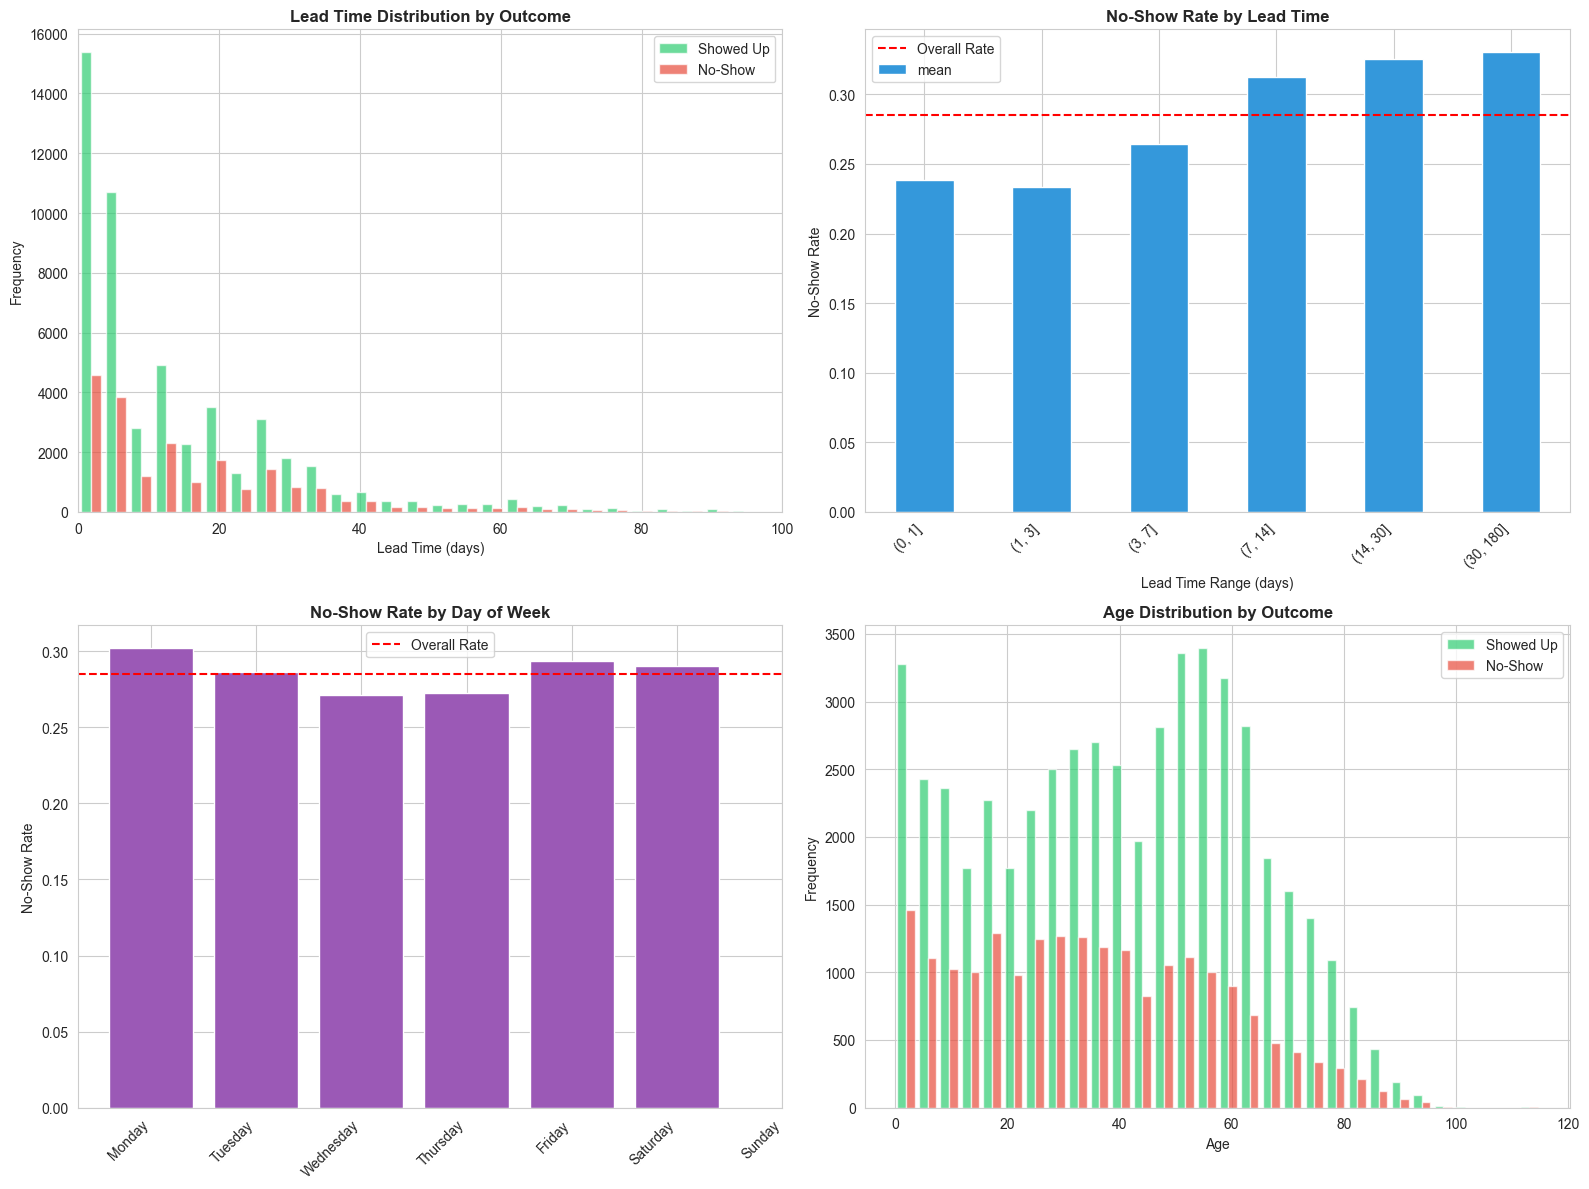

In [4]:
#cell 3: lead time analysis (most important)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#1. lead time distribution by outcome
axes[0, 0].hist([df[df['no_show']==0]['lead_time_days'], 
                  df[df['no_show']==1]['lead_time_days']], 
                 bins=50, label=['Showed Up', 'No-Show'], alpha=0.7, color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_xlabel('Lead Time (days)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Lead Time Distribution by Outcome', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 100)

# 2. No-show rate by lead time bins
lead_time_bins = pd.cut(df['lead_time_days'], bins=[0, 1, 3, 7, 14, 30, 180])
no_show_by_lead = df.groupby(lead_time_bins)['no_show'].agg(['mean', 'count'])
no_show_by_lead['mean'].plot(kind='bar', ax=axes[0, 1], color='#3498db')
axes[0, 1].set_title('No-Show Rate by Lead Time', fontweight='bold')
axes[0, 1].set_xlabel('Lead Time Range (days)')
axes[0, 1].set_ylabel('No-Show Rate')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')
axes[0, 1].axhline(df['no_show'].mean(), color='red', linestyle='--', label='Overall Rate')
axes[0, 1].legend()

#  3. Day of week analysis
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
no_show_by_day = (
    df.groupby('appointment_day_of_week')['no_show']
      .mean()
      .reindex(range(7))   # force 0–6 (Mon–Sun)
)
axes[1, 0].bar(range(7), no_show_by_day.values, color='#9b59b6')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(day_names, rotation=45, ha='right')
axes[1, 0].set_title('No-Show Rate by Day of Week', fontweight='bold')
axes[1, 0].set_ylabel('No-Show Rate')
axes[1, 0].axhline(df['no_show'].mean(), color='red', linestyle='--', label='Overall Rate')
axes[1, 0].legend()

# 4. Age distribution
axes[1, 1].hist([df[df['no_show']==0]['age'], 
                  df[df['no_show']==1]['age']], 
                 bins=30, label=['Showed Up', 'No-Show'], alpha=0.7, color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Age Distribution by Outcome', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(r"C:\Users\darle\Documents\!Bryan Projects\healthcare-no-show-prediction\docs\figures\eda_overview.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\darle\AppData\Local\Temp\ipykernel_11012\1783488763.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  no_show_by_history = df.groupby(history_bins)['no_show'].mean()
C:\Users\darle\AppData\Local\Temp\ipykernel_11012\1783488763.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


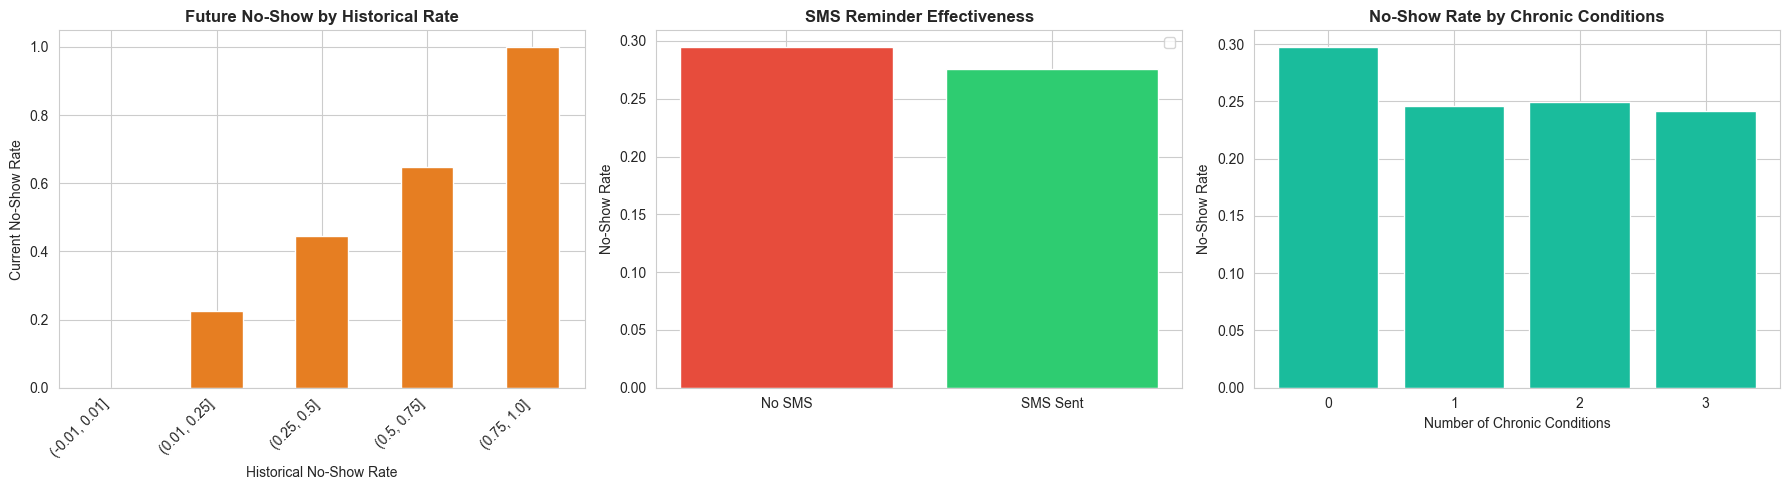

In [5]:
#cell 4: patient history analysis
fig, axes = plt.subplots(1, 3, figsize=(18,5))

#historical no-show rate
history_bins = pd.cut(df['patient_no_show_rate'], bins=[-0.01, 0.01, 0.25, 0.5, 0.75, 1.0])
no_show_by_history = df.groupby(history_bins)['no_show'].mean()
no_show_by_history.plot(kind='bar', ax=axes[0], color='#e67e22')
axes[0].set_title('Future No-Show by Historical Rate', fontweight='bold')
axes[0].set_xlabel('Historical No-Show Rate')
axes[0].set_ylabel('Current No-Show Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

#sms reminder effectiveness
sms_effect = df.groupby('sms_received')['no_show'].mean()
axes[1].bar(['No SMS', 'SMS Sent'], sms_effect.values, color=['#e74c3c', '#2ecc71'])
axes[1].set_title('SMS Reminder Effectiveness', fontweight='bold')
axes[1].set_ylabel('No-Show Rate')
axes[1].legend()

#condition chronic
condition_impact = df.groupby('chronic_condition_count')['no_show'].mean()
axes[2].bar(range(len(condition_impact)), condition_impact.values, color='#1abc9c')
axes[2].set_title('No-Show Rate by Chronic Conditions', fontweight='bold')
axes[2].set_xlabel('Number of Chronic Conditions')
axes[2].set_ylabel('No-Show Rate')
axes[2].set_xticks(range(len(condition_impact)))

plt.tight_layout()
plt.savefig(r"C:\Users\darle\Documents\!Bryan Projects\healthcare-no-show-prediction\docs\figures\patient_history_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
#cell 5: interactive plotly heatmap
#no show rate by day and hour (if hour data is available)
#creates business-ready visualization

#agg data
heatmap_data = df.groupby(['appointment_day_of_week', 'appointment_month'])['no_show'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='appointment_day_of_week', columns='appointment_month', values='no_show')

# create heatmap
fig = px.imshow(heatmap_pivot,
               labels=dict(x="Month", y="Day of Week", color="No-Show Rate"),
               color_continuous_scale='RdYlGn_r',
               title='No-Show Risk Heatmap: Day of Week vs Month')

fig.update_xaxes(side="bottom")
fig.update_layout(height=500, width=800)
fig.show()

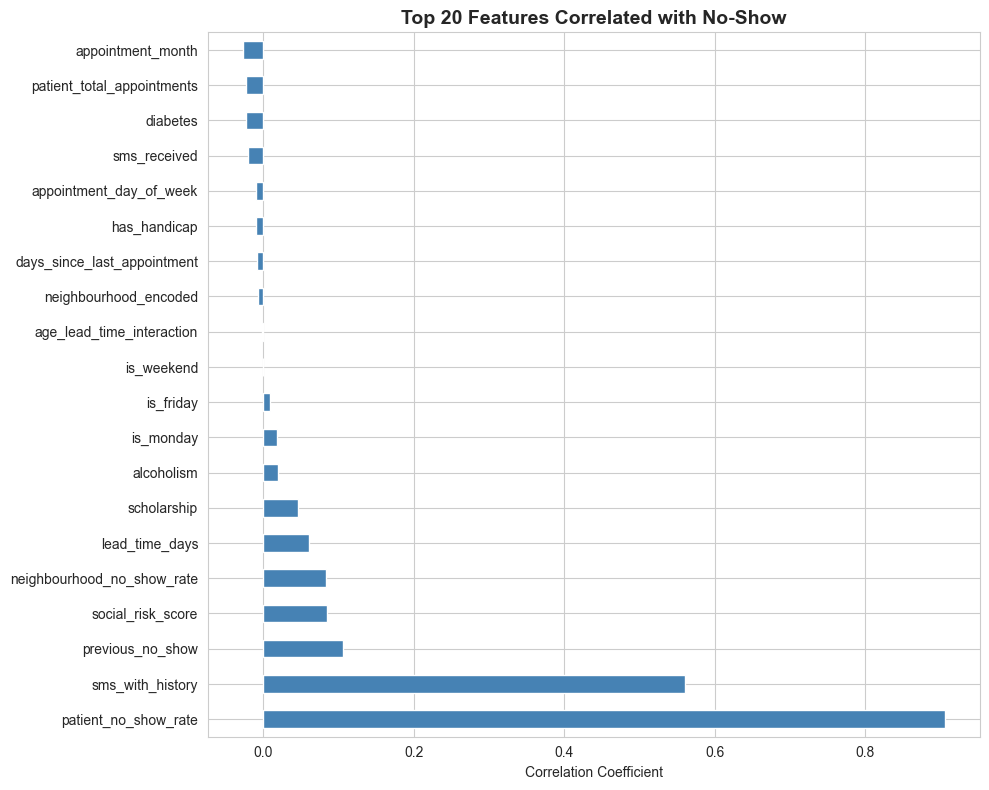


Top 10 Correlated Features with No-Show:
no_show                        1.000000
patient_no_show_rate           0.905888
sms_with_history               0.560743
previous_no_show               0.106049
social_risk_score              0.085099
neighbourhood_no_show_rate     0.083867
lead_time_days                 0.060362
scholarship                    0.045687
alcoholism                     0.019864
is_monday                      0.018886
is_friday                      0.008490
is_weekend                     0.000236
age_lead_time_interaction     -0.002025
neighbourhood_encoded         -0.007332
days_since_last_appointment   -0.007619
has_handicap                  -0.008930
appointment_day_of_week       -0.010094
sms_received                  -0.020631
diabetes                      -0.022412
patient_total_appointments    -0.023034
appointment_month             -0.026916
chronic_condition_count       -0.042965
scheduled_same_day            -0.044371
has_chronic_condition         -0.04716

In [ ]:
#cell 6: correlation analysis
#numeric features selection
features_numeric = df.select_dtypes(include=[np.number]).columns.tolist() #select_dtypes is a function in pandas library (which only takes the column names with dtype integer)

#remove id columns if available
features_numeric = [col for col in features_numeric if not col.endswith('_id')] #iterates through the column ad remove column that name endswith '_id'

#plot top correlations
correlations = df[features_numeric].corr()['no_show'].sort_values(ascending=False) #sorts from highest to lowest

#plot top correlations
plt.figure(figsize=(10, 8))
correlations[1:21].plot(kind='barh', color='steelblue') #top 20, exclude target itself
plt.title('Top 20 Features Correlated with No-Show', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.savefig(r"C:\Users\darle\Documents\!Bryan Projects\healthcare-no-show-prediction\docs\figures\features_correlations.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Correlated Features with No-Show:")
print(correlations[1:11])

In [ ]:
#cell 7: business insights summary
print("=" * 70)
print(" " * 20 + "KEY BUSINESS INSIGHTS")
print("=" * 70)

print("\n1. Lead Time is the Stronges Predictor")

# Select only same-day appointments (scheduled_same_day = 1), take their no_show values, compute the mean to get the no-show rate,and print the result as a percentage
print(f"  > Same day appointments: {df[df['scheduled_same_day'] == 1]['no_show'].mean():.1%} no-show rate")
print(f"  > 1-3 Days ahead: {df[(df['lead_time_days'] > 0) & (df['lead_time_days']<=3)]['no_show'].mean():.1%} no-show rate")
print(f"  > 30+ Days ahead: {df[df['lead_time_days'] > 30]['no_show'].mean():.1%} no-show rate")

print("\n2. Patient History Matters")
high_risk_patients = df[df['patient_no_show_rate'] > 0.5] #remove rows (not columns) which patient no show rate greater than 0.5
print(f"  > Patients with >50% historical no-show rate: {len(high_risk_patients):,} ({len(high_risk_patients)/len(df):.1%})")
print(f"  > Their current no-show rate: {high_risk_patients['no_show'].mean():.1%}")
print(f"  !! Recommendation: Prioritize the interventions for repeat offenders")

print("\n3. SMS Reminders Reduce No-Shows")
print(f"  > With SMS: {df[df['sms_received']==1]['no_show'].mean():.1%} no-show rate")
print(f"  > Without SMS: {df[df['sms_received']==0]['no_show'].mean():.1%} no-show rate")
reduction = ((df[df['sms_received']==0]['no_show'].mean() - df[df['sms_received']==1]['no_show'].mean()) / 
             df[df['sms_received']==0]['no_show'].mean() * 100)
print(f"  > Relative reduction: {reduction:.1f}%")
print(f"  !! Recommendation: Universal SMS reminders 48 hours before appointment")

print("\n4. Day Of Week Patterns")
worst_day = day_names[no_show_by_day.idxmax()]
best_day = day_names[no_show_by_day.idxmin()]
print(f"  > Worst day: {worst_day} ({no_show_by_day.max():.1%} no-show rate)")
print(f"  > Best day: {best_day} ({no_show_by_day.min():.1%} no-show rate)")
print(f"  !! Recommendation: Consider overbooking by 15% on {worst_day}s")

print("\n5. Financial Impact")
total_no_shows = df['no_show'].sum()
estimated_loss = total_no_shows * 200
print(f"  > Total no-shows in dataset: {total_no_shows:,}")
print(f"  > Estimated revenue loss: ${estimated_loss:,}")
print(f"  > If we reduce no-shows by 30%: ${estimated_loss * 0.3:,.0f} saved annually")

print("\n" + "="*70)

                    KEY BUSINESS INSIGHTS

1. Lead Time is the Stronges Predictor
  > Same day appointments: 21.4% no-show rate
  > 1-3 Days ahead: 23.6% no-show rate
  > 30+ Days ahead: 33.0% no-show rate

2. Patient History Matters
  > Patients with >50% historical no-show rate: 17,050 (23.7%)
  > Their current no-show rate: 96.9%
  !! Recommendation: Prioritize the interventions for repeat offenders

3. SMS Reminders Reduce No-Shows
  > With SMS: 27.6% no-show rate
  > Without SMS: 29.4% no-show rate
  > Relative reduction: 6.3%
  !! Recommendation: Universal SMS reminders 48 hours before appointment

4. Day Of Week Patterns
  > Worst day: Monday (30.2% no-show rate)
  > Best day: Wednesday (27.1% no-show rate)
  !! Recommendation: Consider overbooking by 15% on Mondays

5. Financial Impact
  > Total no-shows in dataset: 20,522
  > Estimated revenue loss: $4,104,400
  > If we reduce no-shows by 30%: $1,231,320 saved annually

